In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from moviepy.video.io.ImageSequenceClip import ImageSequenceClip
import glob, natsort, os

from src.metadata_utils import extract_metadata
from src.metadata_utils import DHM_data_extraction, CVM_data_extraction, PUND_data_extraction
from src.metadata_utils import fatigue_data_extraction
from src.metadata_utils import fatigue_dataframe_extraction
from src.Plot import main_plot
from src.Plot import Plot_single_DHM, Plot_single_CVM, Plot_single_PUND
from src.Plot import Plot_multi_DHM, Plot_multi_CVM, Plot_multi_PUND
from src.export import main_export_csv, export_csv_DHM, export_csv_CVM, export_csv_PUND, export_csv_PUND_origin_friendly

#-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# This code is used to plot the data from the FE tester for the CV
#------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

%config InlineBackend.figure_format = 'retina' # For high resolution figures in Jupyter Notebook
#%matplotlib widget

---

## Operator window

#### Parameters to Specify

- **Input file path**  
- **Output file path**  
- **File name**  
- **Number of points to remove** (in case of breakdown)
- **1 or 0 if you want a video from the measurement plot** (may take a long time if nemerous plot are present)

⚠️ **Important:** Pay attention to the **output path**. The program will automatically create **3 subfolders** and an additional subfolder for each different kind of measurement done during the endurance in the output path to store the plots, a video and the CSV file.

In [2]:
# Set the path to the data file
# ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

file_path = r'C:\Users\natha\Documents\Polybox back up 2026-03-28\01 - Top electrode engineering\02 - Data\02 - FE tester\NASA-002-01\Endurance measurement'
output_path = r'C:\Users\natha\Documents\Polybox back up 2026-03-28\01 - Top electrode engineering\02 - Data\02 - FE tester\NASA-002-01\Endurance measurement'
file_name = '2025-11-12_NASA-002-01_ID06-21_FM'
file_name = file_name + ".dat"
full_path = os.path.join(file_path, file_name)

# If we have a breakdown during the measurement, we can remove the last n points
point_removal = 0

# 1 if you want a video from the DHM plot (may take a long time if nemerous plot are present), 0 otherwise
video_allowed = 0 

# Extract the last folder name from the file path
last_folder = os.path.basename(os.path.dirname(file_path))

# Séparer nom et extension
base_name = os.path.splitext(file_name)[0]
print(f"Device name: {base_name}")  # ➜ NASA_SL_ALE_10_ID_095
output_path = os.path.join(output_path, base_name)
print(f"Output path: {output_path}")

Device name: 2025-11-12_NASA-002-01_ID06-21_FM
Output path: C:\Users\natha\Documents\Polybox back up 2026-03-28\01 - Top electrode engineering\02 - Data\02 - FE tester\NASA-002-01\Endurance measurement\2025-11-12_NASA-002-01_ID06-21_FM


---

## Complete fatigue analysis

### 1. File extraction
Parses the `.dat` file and splits the data by measurement type (DHM, CVM, PUND).

In [3]:
# The function used in this cell are stored in the src folder

# --- Get the lines where the information of the fatigue measurement are stored ---
data_lines_complete_fatigue = fatigue_data_extraction(full_path)

# --- Initialize metadata placeholders ---
metadata_dict_DHM, metadata_dict_CVM, metadata_dict_PUND, metadata_str_DHM, metadata_str_CVM, metadata_str_PUND = extract_metadata(data_lines_complete_fatigue, point_removal, keyword="Hysteresis")

# --- Extract the dataframe of the fatigue measurement into a pandas series to plot the curves ---
df_fatigue_DHM, df_fatigue_CVM, df_fatigue_PUND, Cycles_total = fatigue_dataframe_extraction(data_lines_complete_fatigue, point_removal, metadata_dict_DHM, metadata_dict_CVM, metadata_dict_PUND)


Found the start of the table block at line 10: Result Table 1
Found the end of the table block at line 443: Data Table [1,1]
DHM is present:True, number : 1
CVM is present: True, number : 2
PUND is present: True, number : 3
Data header found at relative line 20, end marker at 114


### 2. Data analysis & CSV export
Builds the dataframes for each measurement type and exports them as CSV files.

In [4]:

DHM_dataframe = DHM_data_extraction(full_path, Cycles_total, point_removal, df_fatigue_DHM, metadata_dict_DHM)
CVM_dataframe = CVM_data_extraction(full_path, Cycles_total, point_removal, df_fatigue_CVM, metadata_dict_CVM)
PUND_dataframe = PUND_data_extraction(full_path, Cycles_total, point_removal, df_fatigue_PUND, metadata_dict_PUND)

# --- Export the data as CSV files ---
export_csv_DHM(DHM_dataframe, metadata_dict_DHM, output_path, base_name)
export_csv_CVM(CVM_dataframe, metadata_dict_CVM, output_path, base_name)
export_csv_PUND(PUND_dataframe, metadata_dict_PUND, output_path, base_name)
export_csv_PUND_origin_friendly(PUND_dataframe, metadata_dict_PUND, output_path, base_name)

92 DHM dataframe loaded.
92 CVM dataframe loaded.
92 PUND dataframe loaded.


### 3. Main fatigue plot
Plots Pr, Ec, and leakage vs. cycle count for all measurement types. Also exports a summary CSV.

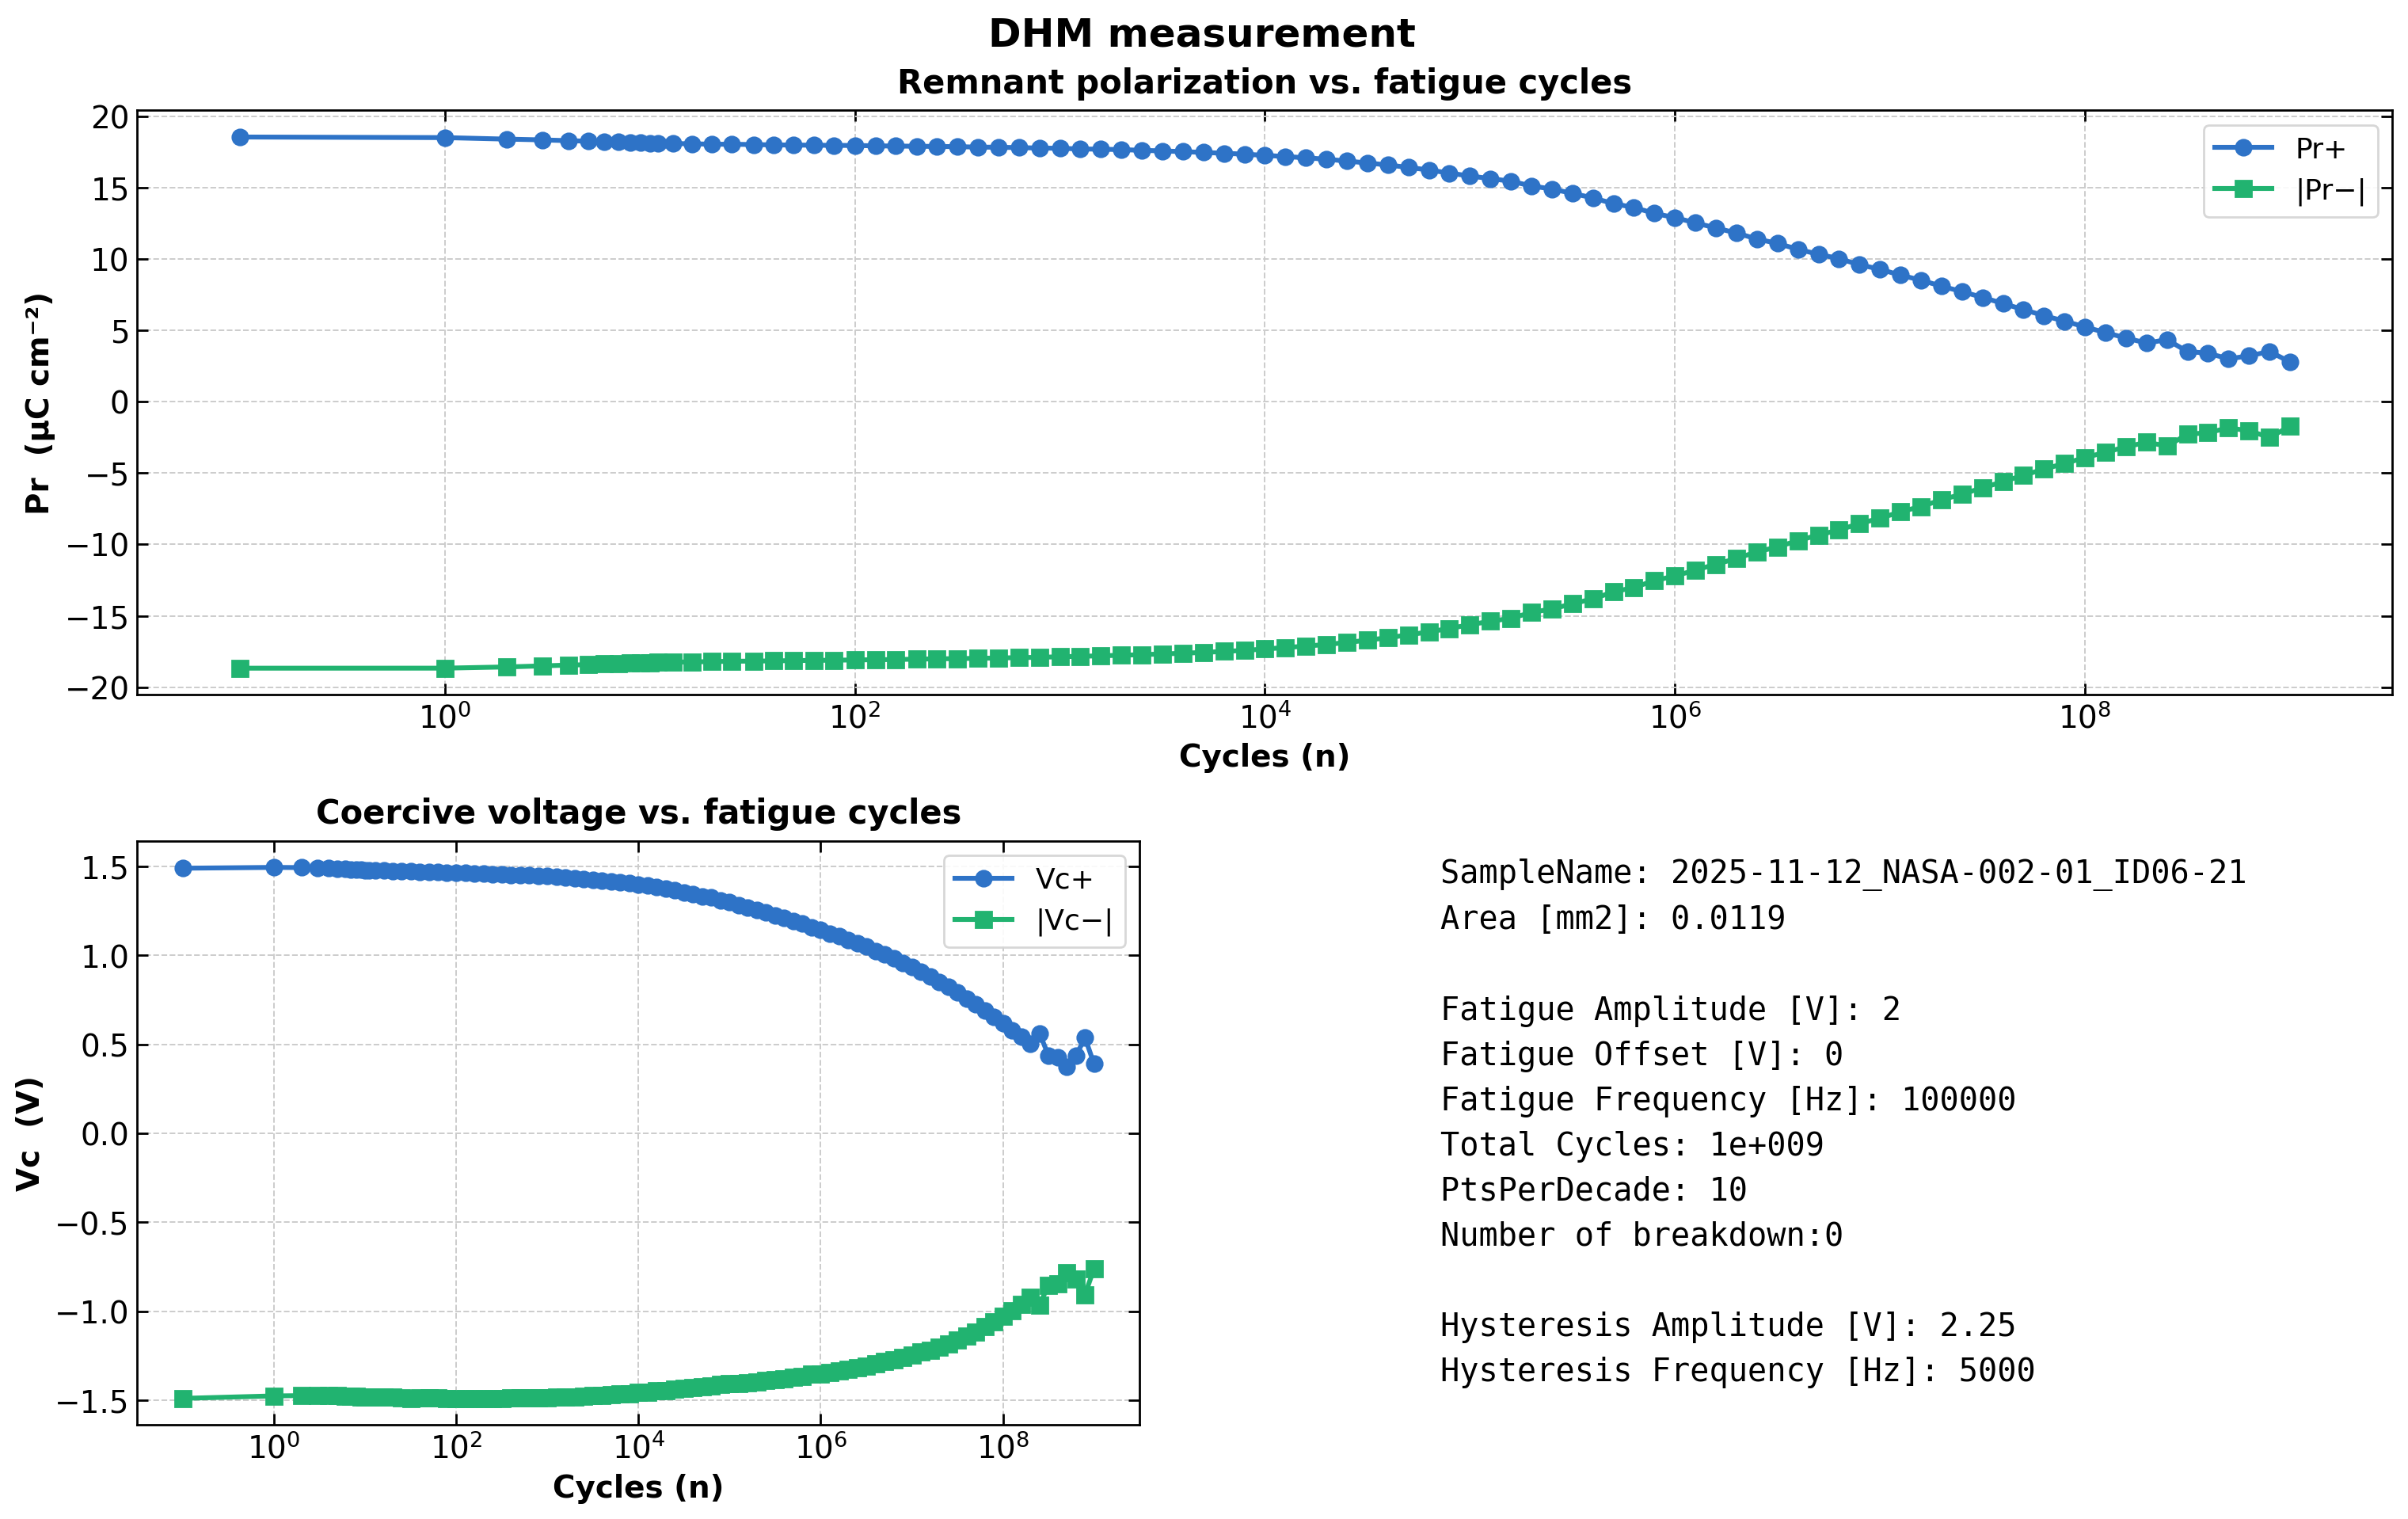

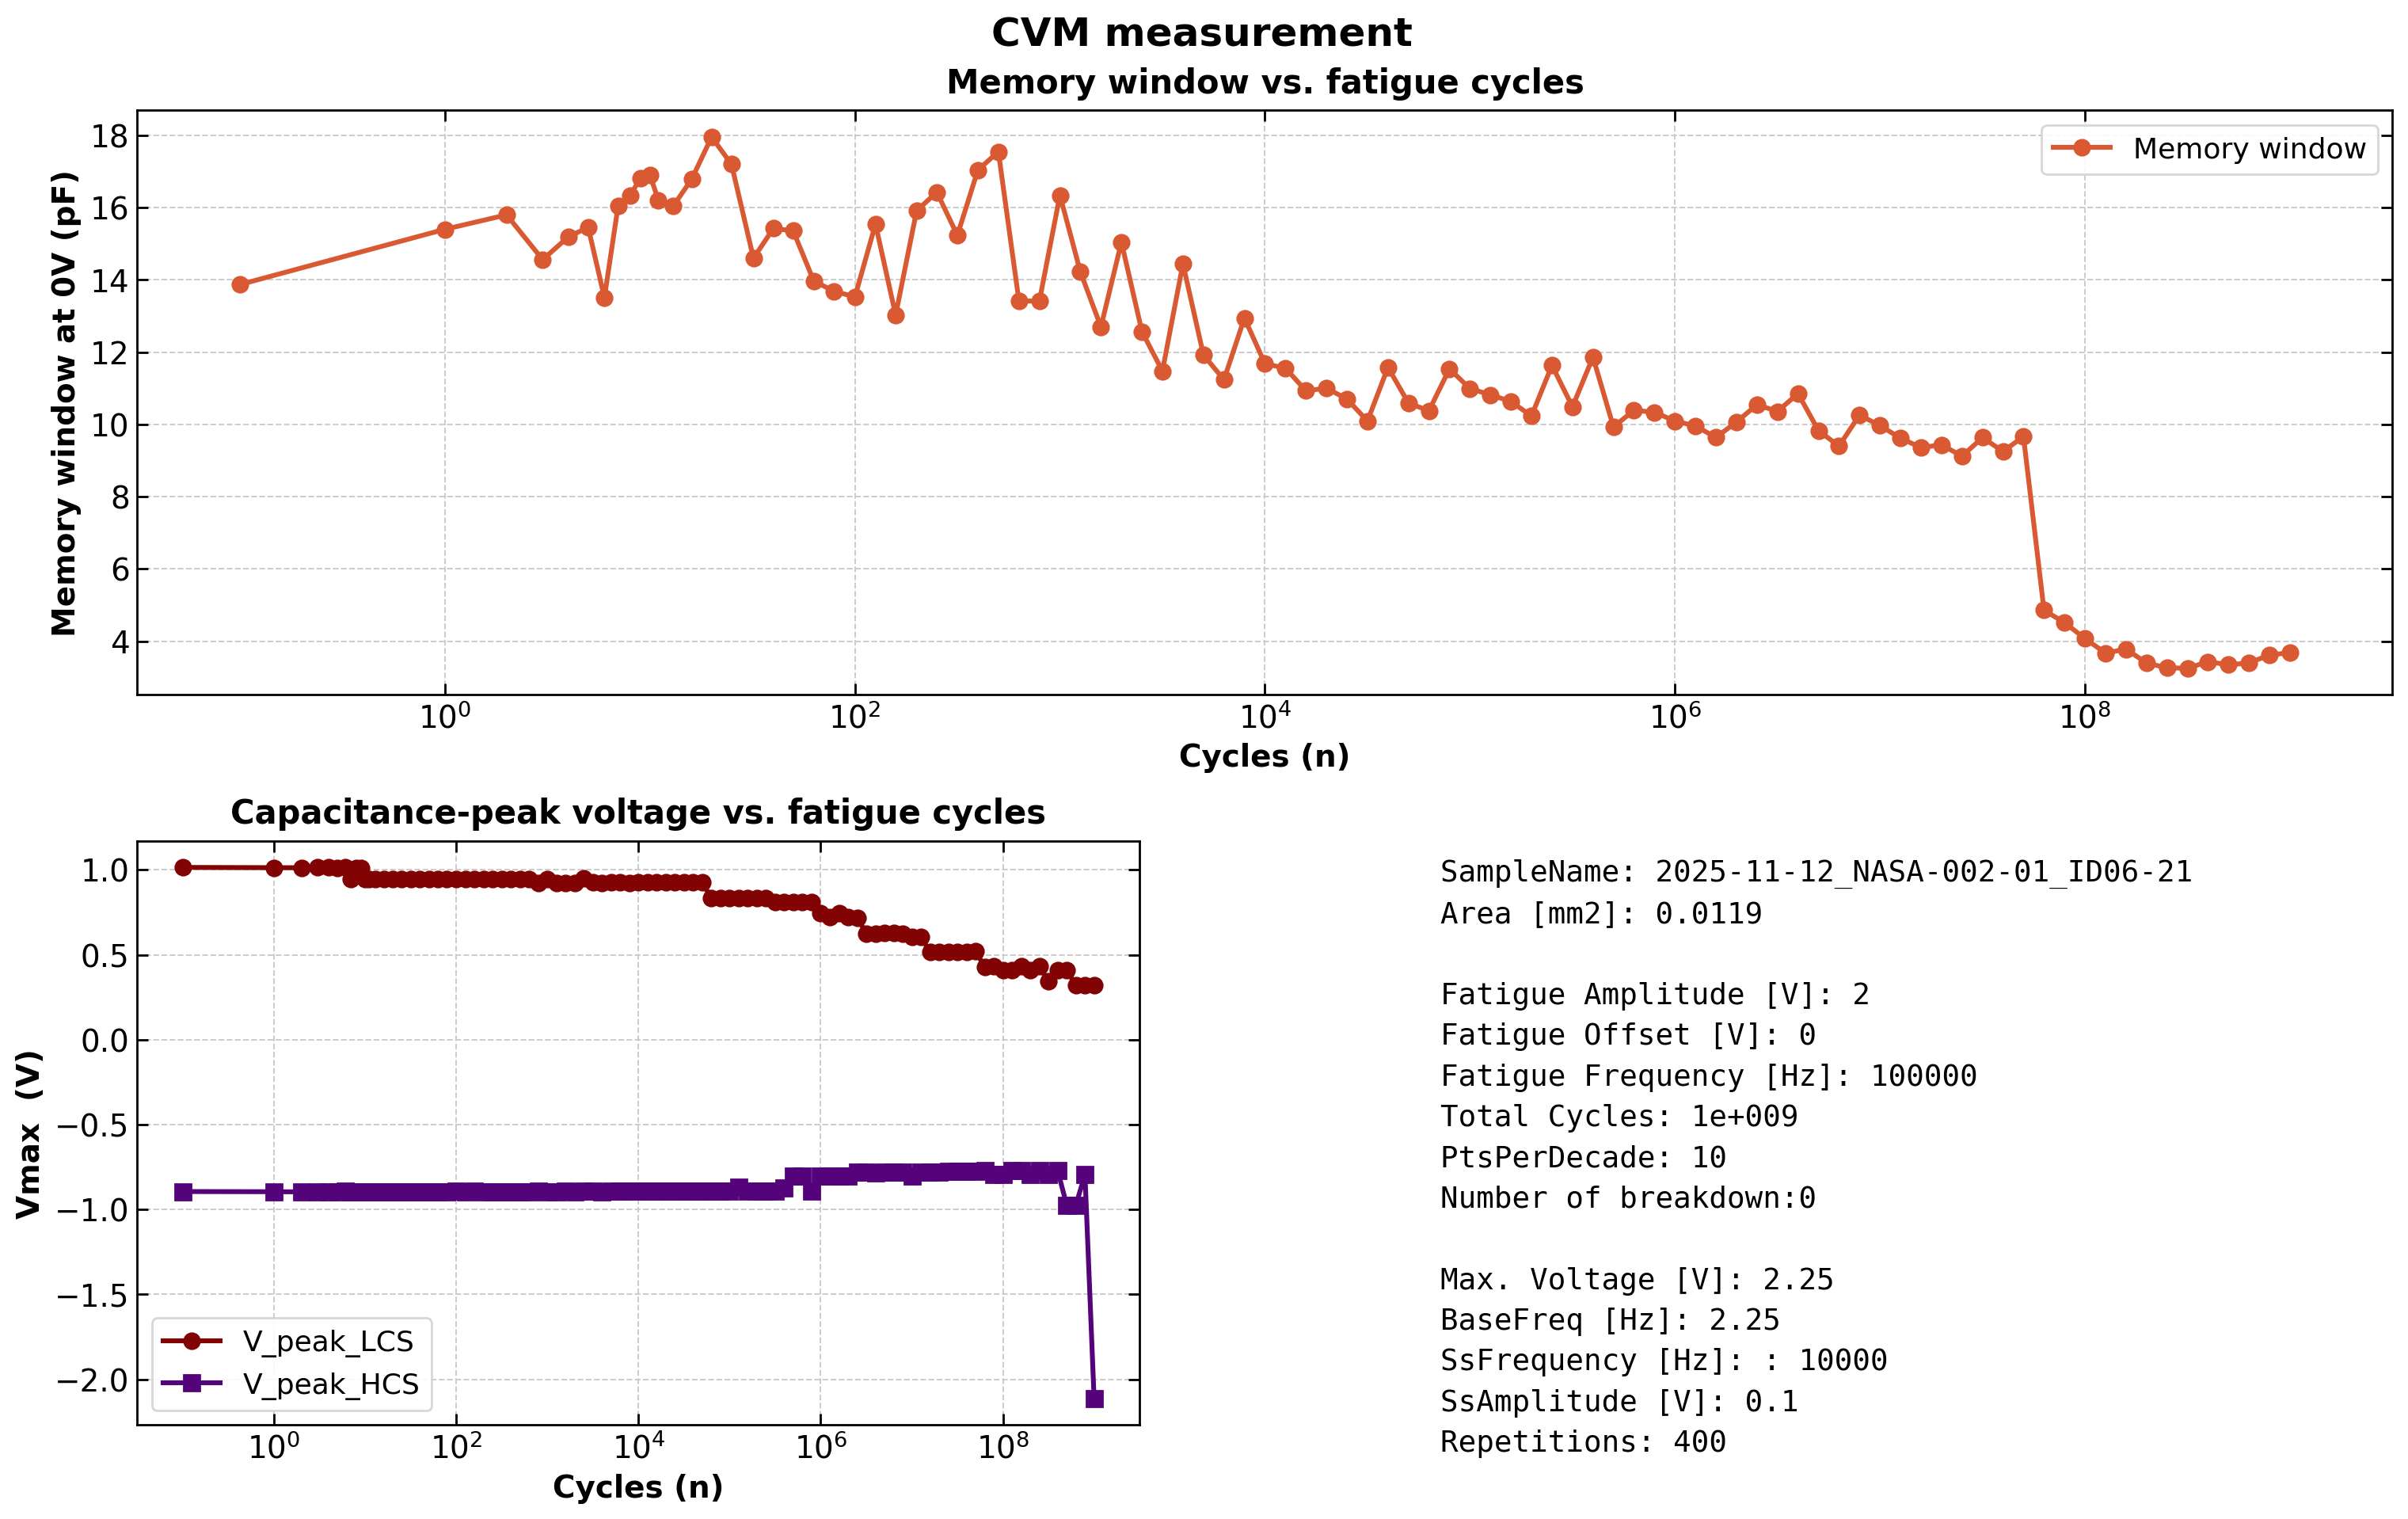

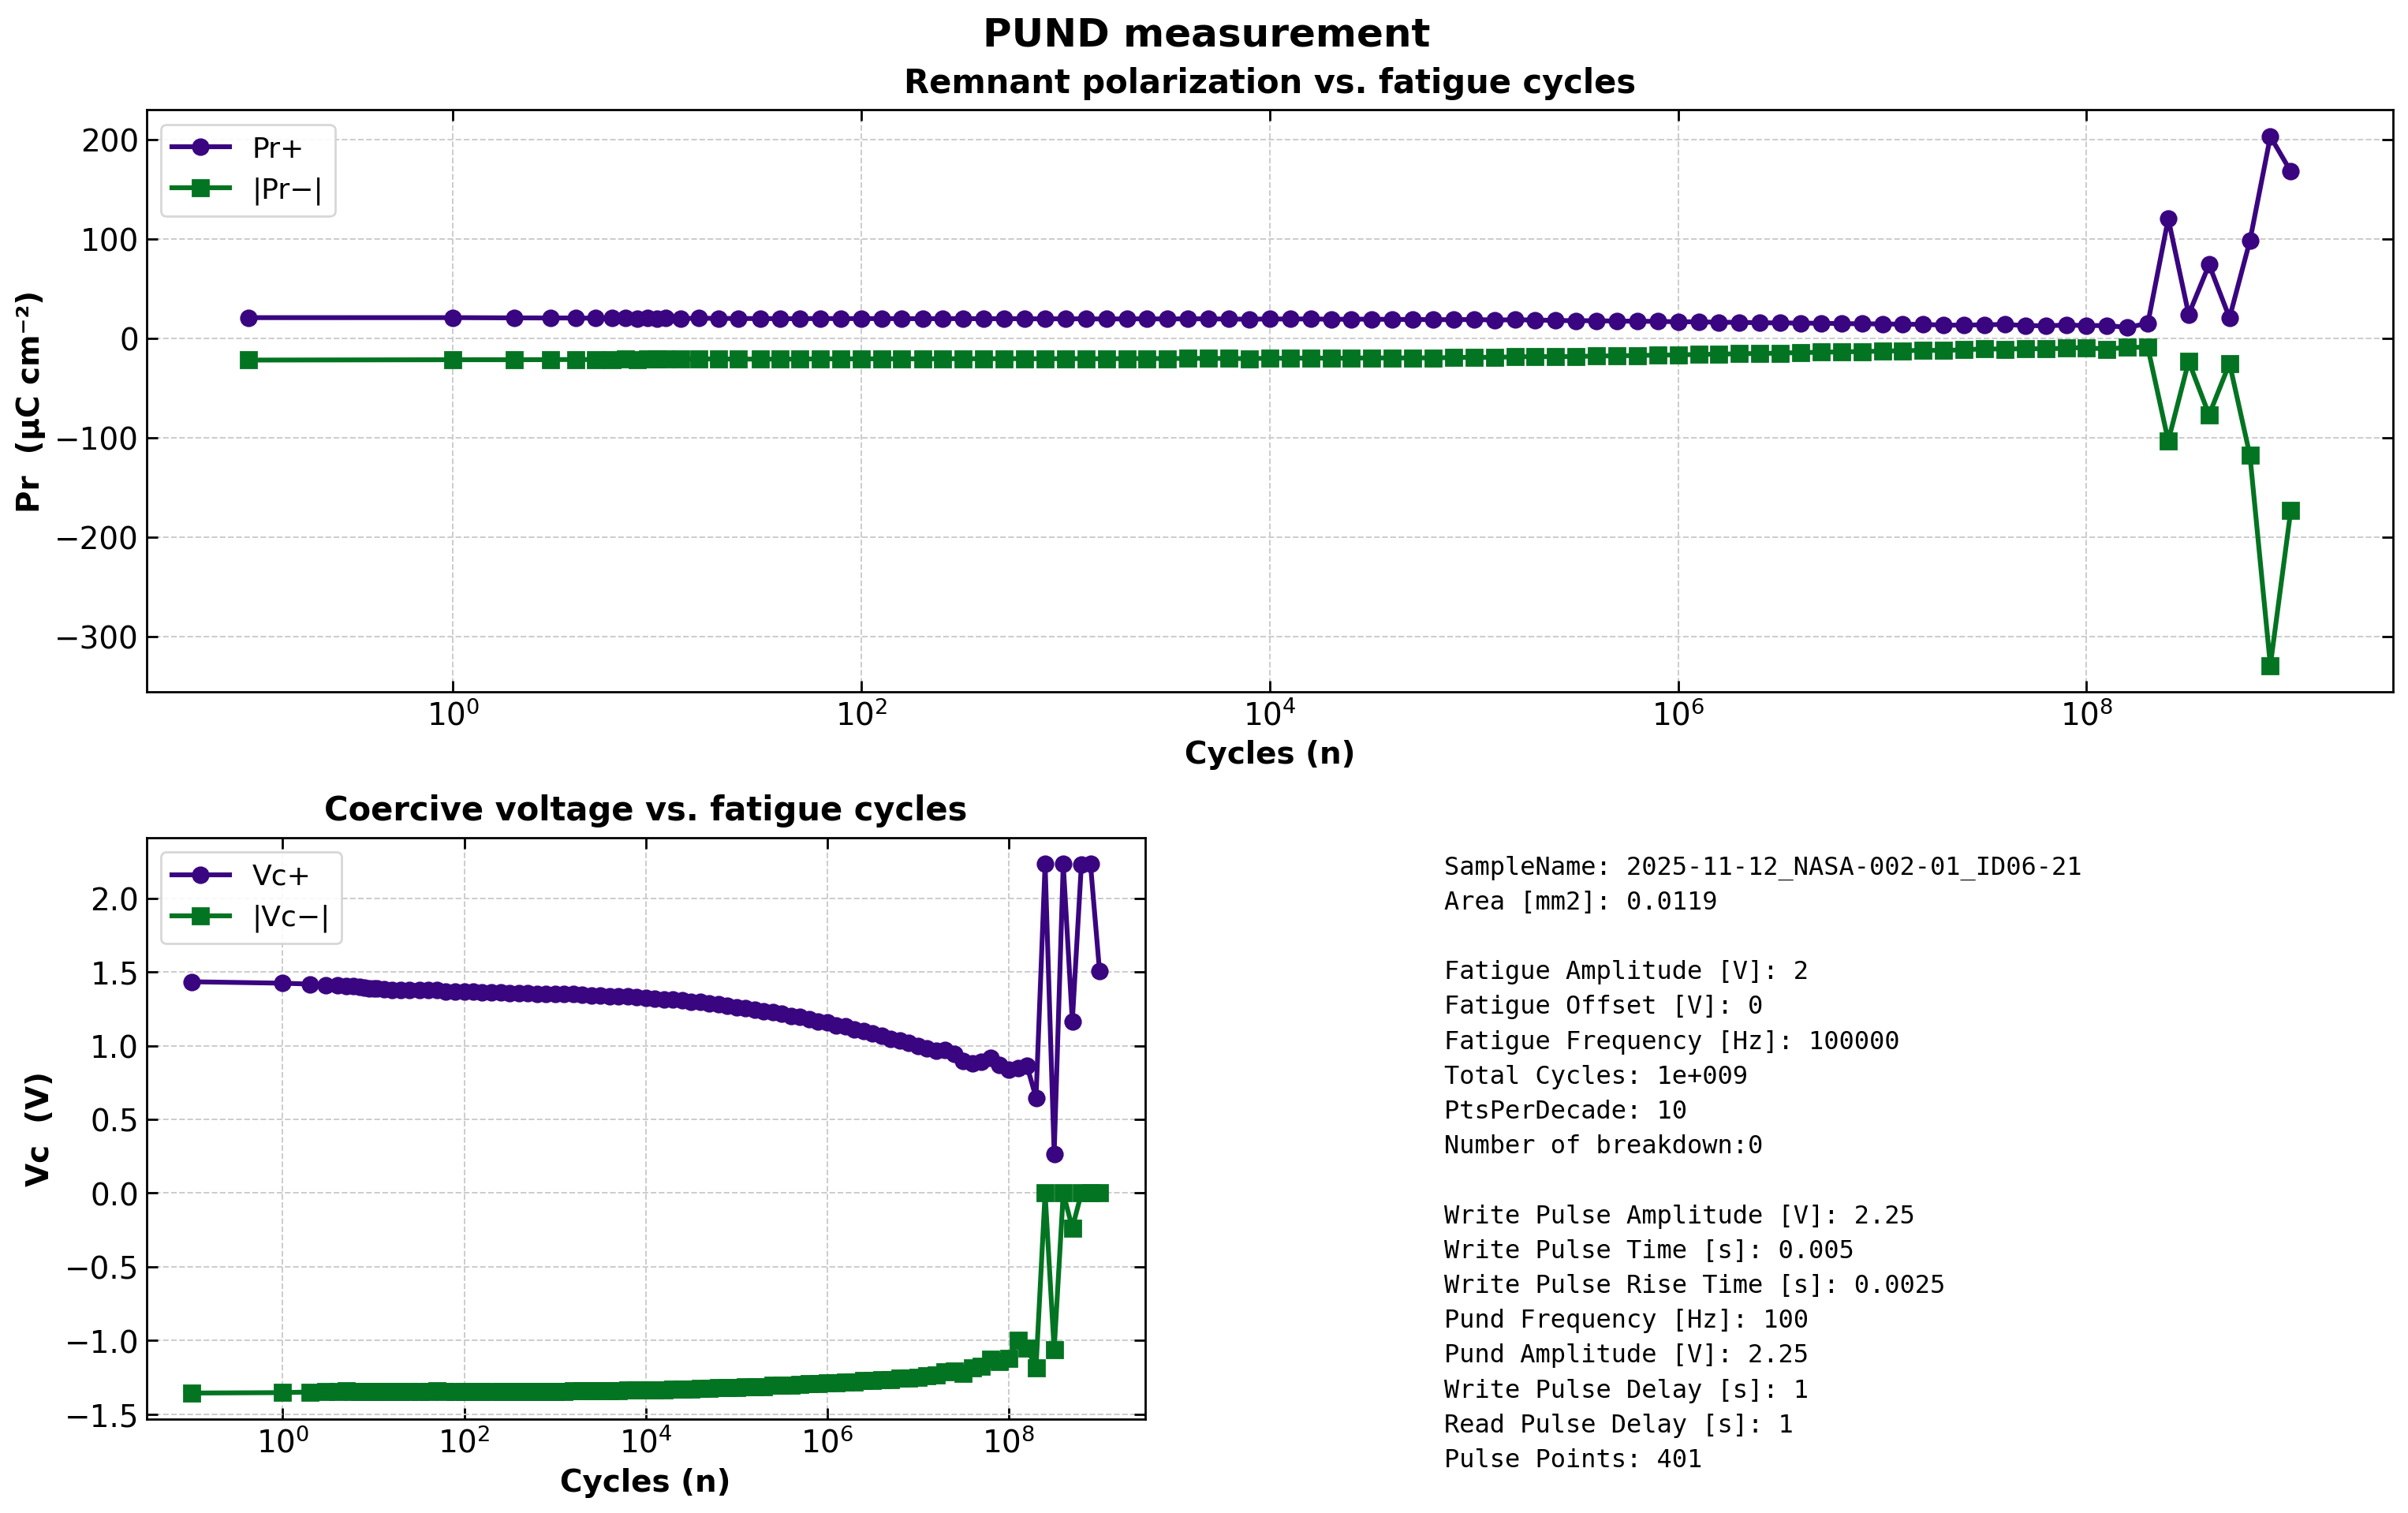

In [5]:
# --- Plot the fatigue data ---

label_size = 14
Save_main_plot = True

main_plot(df_fatigue_DHM, df_fatigue_CVM, df_fatigue_PUND, CVM_dataframe,
          metadata_dict_DHM, metadata_dict_CVM, metadata_dict_PUND, 
          metadata_str_DHM, metadata_str_CVM, metadata_str_PUND, 
          output_path, base_name, label_size)

main_export_csv(df_fatigue_DHM, df_fatigue_CVM, df_fatigue_PUND, 
                metadata_dict_DHM, metadata_dict_CVM, metadata_dict_PUND, 
                output_path, base_name)


---

### 4. Single overlay plot
Overlays all cycles on a single axes for DHM, CVM, and PUND — useful for shape evolution.

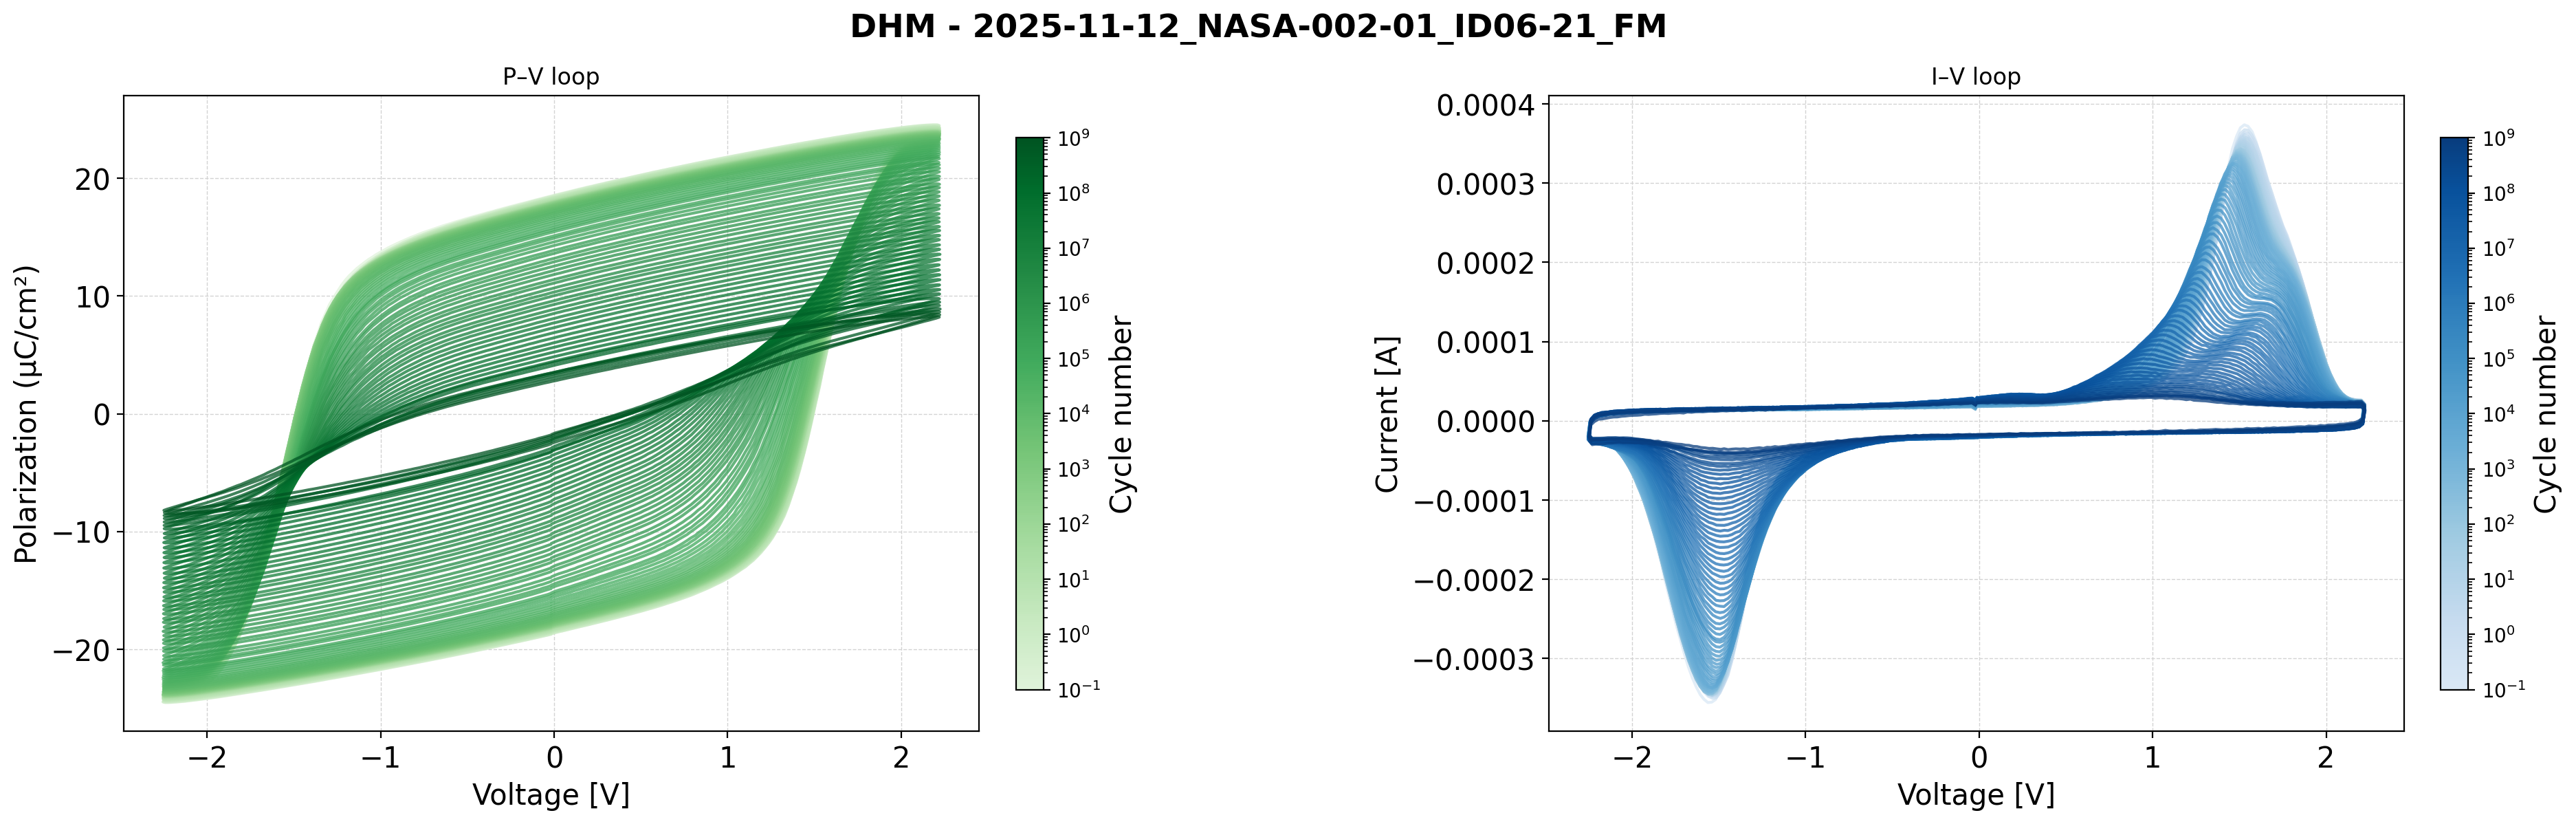

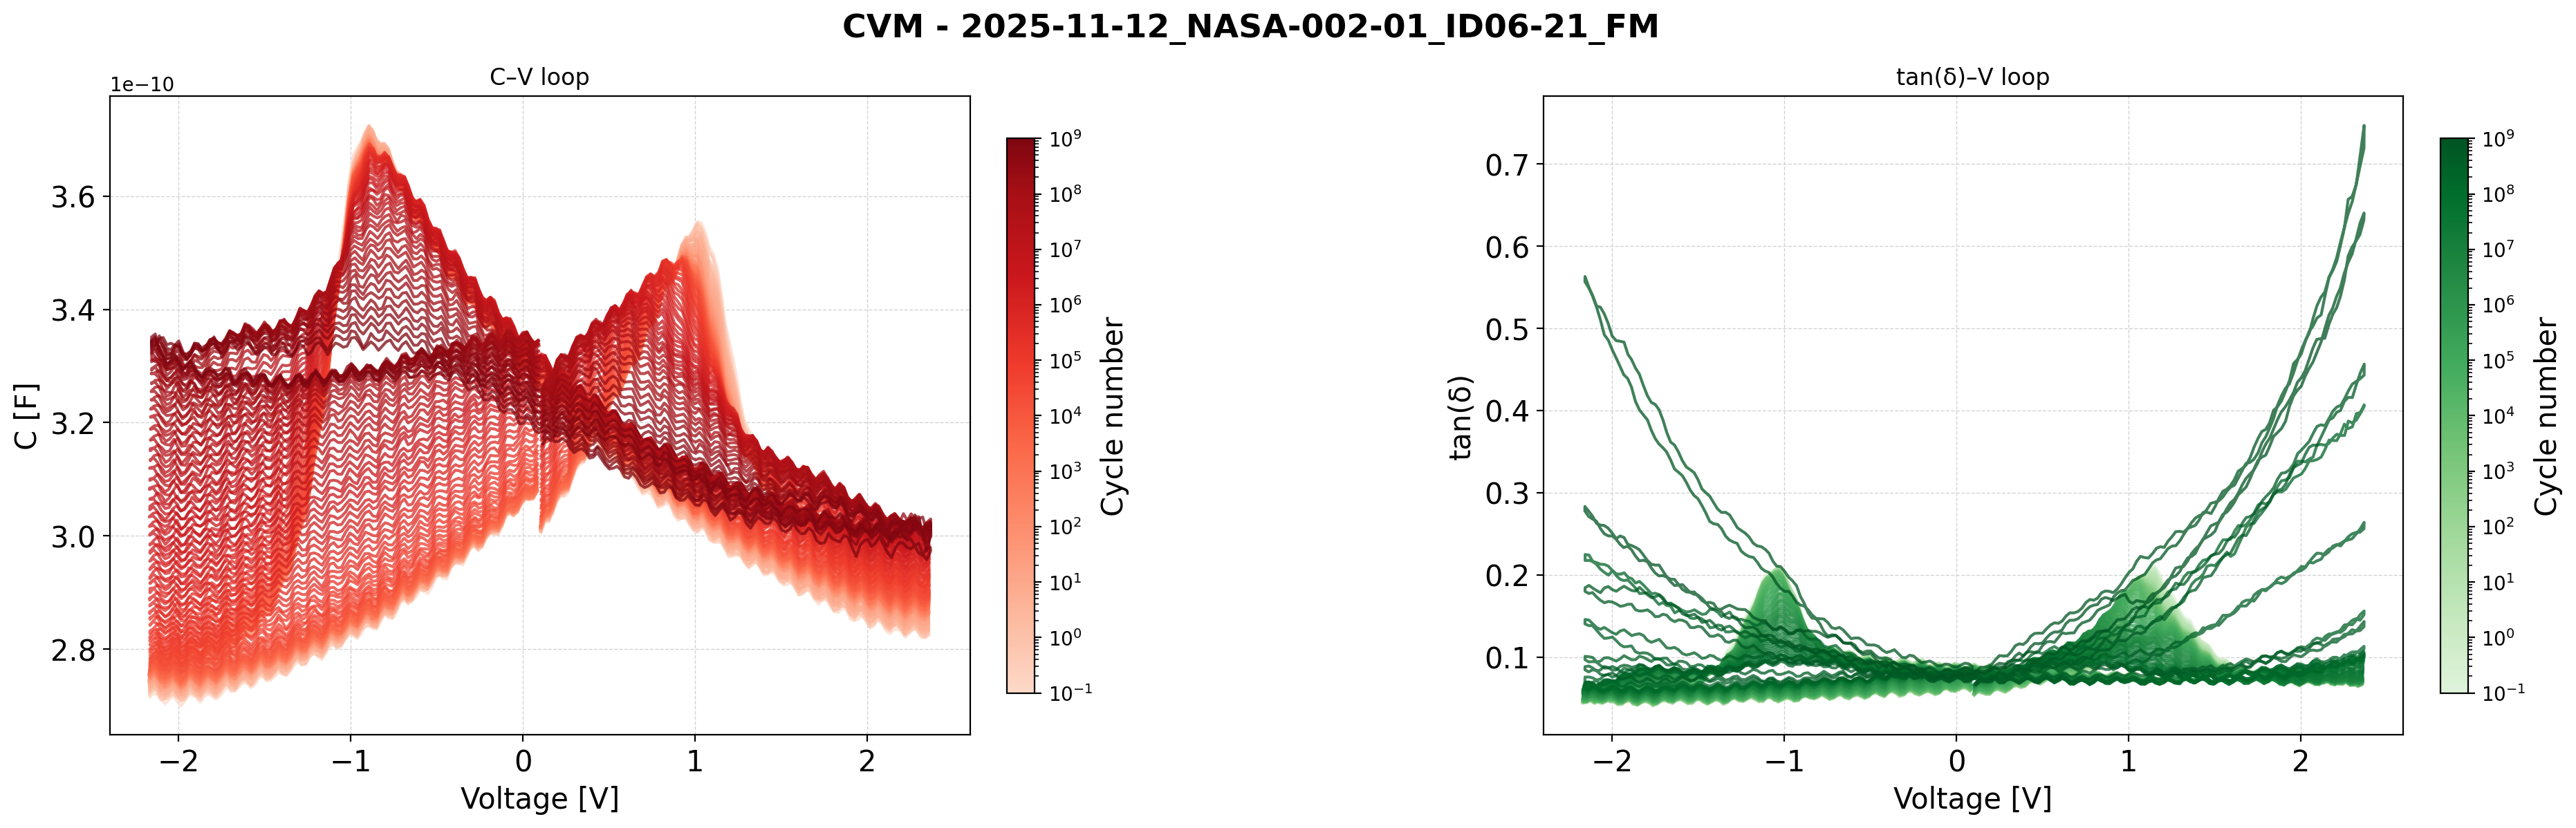

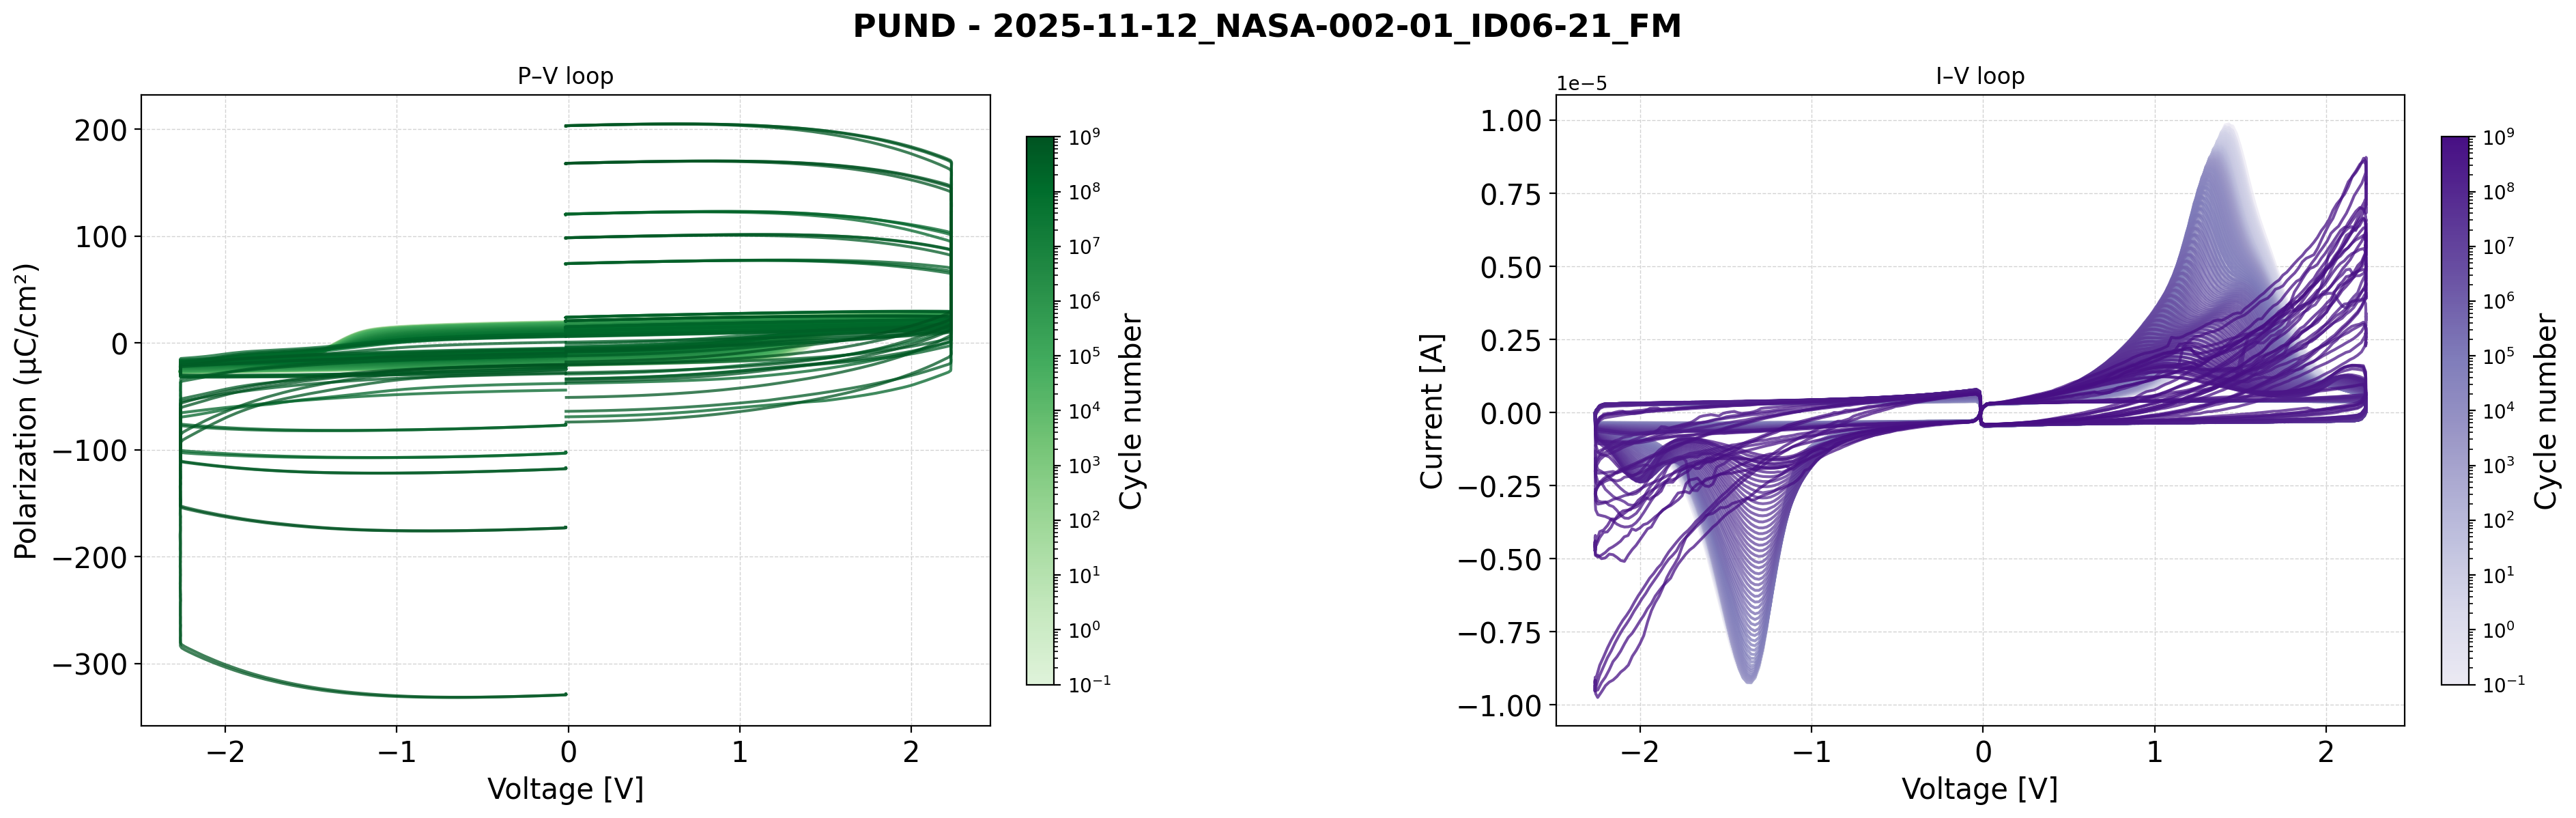

In [6]:
# Ploting of every DHM curve into a single plot.
label_size = 15
output_main_plot = os.path.join(output_path, "Main plot")
os.makedirs(output_main_plot, exist_ok=True) # Ensure output directory exists

Plot_single_DHM(DHM_dataframe, Cycles_total, label_size, output_main_plot, base_name, metadata_dict_DHM)
Plot_single_CVM(CVM_dataframe, Cycles_total, label_size, output_main_plot, base_name, metadata_dict_CVM)
Plot_single_PUND(PUND_dataframe, Cycles_total, label_size, output_main_plot, base_name, metadata_dict_PUND)

### 5. Multi-plot & video
Saves one plot per cycle. If `video_allowed = 1`, assembles them into `.mp4` files (slow for large datasets).

In [7]:
# Plot of every DHM curve.

label_size = 13
Plot_multi_DHM(DHM_dataframe,output_path, Cycles_total, label_size, base_name, metadata_dict_DHM)
Plot_multi_CVM(CVM_dataframe,output_path, Cycles_total, label_size, base_name, metadata_dict_CVM)
Plot_multi_PUND(PUND_dataframe,output_path, Cycles_total, label_size, base_name, metadata_dict_PUND)

if video_allowed == 1:
    # --- Create a video from the DHM plots ---

    output_plot_DHM = os.path.join(output_path, "DHM plot")
    output_plot_CVM = os.path.join(output_path, "CVM plot")
    output_plot_PUND = os.path.join(output_path, "PUND plot")
    output_video = os.path.join(output_path, "Video")
    os.makedirs(output_plot_DHM, exist_ok=True)  # Ensure output directory exists
    os.makedirs(output_video, exist_ok=True)  # Ensure output directory exists

    # === Paramètres à donner par l’opérateur ===
    fps = 11   # images par seconde (modifiable)
    outfile_DHM = "dhm_fatigue.mp4"
    outfile_CVM = "cvm_fatigue.mp4"
    outfile_PUND = "pund_fatigue.mp4"
    output_video_DHM = os.path.join(output_video, outfile_DHM)
    output_video_CVM = os.path.join(output_video, outfile_CVM)
    output_video_PUND = os.path.join(output_video, outfile_PUND)

    # Récupère et trie les fichiers PNG
    files_DHM = natsort.natsorted(glob.glob(os.path.join(output_plot_DHM, "*.png")))
    file_CVM = natsort.natsorted(glob.glob(os.path.join(output_plot_CVM, "*.png")))
    file_PUND = natsort.natsorted(glob.glob(os.path.join(output_plot_PUND, "*.png")))

    if not files_DHM:
        print(f"❌ Aucun fichier .png trouvé dans {output_plot_DHM}")
    else:
        clip_DHM = ImageSequenceClip(files_DHM, fps=fps)
        clip_DHM.write_videofile(output_video_DHM, codec="libx264", audio=False, fps=fps)
        print(f"✅ Vidéo générée : {outfile_DHM}")
    if not file_CVM:
        print(f"❌ Aucun fichier .png trouvé dans {output_plot_CVM}")
    else:
        clip_CVM = ImageSequenceClip(file_CVM, fps=fps)
        clip_CVM.write_videofile(output_video_CVM, codec="libx264", audio=False, fps=fps)
        print(f"✅ Vidéo générée : {outfile_CVM}")
    if not file_PUND:
        print(f"❌ Aucun fichier .png trouvé dans {output_plot_PUND}")
    else:
        clip_PUND = ImageSequenceClip(file_PUND, fps=fps)
        clip_PUND.write_videofile(output_video_PUND, codec="libx264", audio=False, fps=fps)
        print(f"✅ Vidéo générée : {outfile_PUND}")


